In [2]:
# 匯入資料
import pandas as pd

# ====== 檔案路徑 ======
file_transaction = "/work/claire901114/初賽資料/acct_transaction.csv"
file_alert = "/work/claire901114/初賽資料/acct_alert.csv"
file_predict = "/work/claire901114/初賽資料/acct_predict.csv"

# ====== 讀取檔案 ======
df_transaction = pd.read_csv(file_transaction)
df_alert = pd.read_csv(file_alert)
df_predict = pd.read_csv(file_predict)

# ====== 檢查資料結構 ======
print("📂 acct_transaction.csv")
print(df_transaction.info())
print(df_transaction.head(), "\n")

print("📂 acct_alert.csv")
print(df_alert.info())
print(df_alert.head(), "\n")

print("📂 acct_predict.csv")
print(df_predict.info())
print(df_predict.head(), "\n")

📂 acct_transaction.csv
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4435890 entries, 0 to 4435889
Data columns (total 10 columns):
 #   Column          Dtype  
---  ------          -----  
 0   from_acct       object 
 1   from_acct_type  int64  
 2   to_acct         object 
 3   to_acct_type    int64  
 4   is_self_txn     object 
 5   txn_amt         float64
 6   txn_date        int64  
 7   txn_time        object 
 8   currency_type   object 
 9   channel_type    object 
dtypes: float64(1), int64(3), object(6)
memory usage: 338.4+ MB
None
                                           from_acct  from_acct_type  \
0  be6fdd2d0f9aa02b0b09436fb137654942e3346e16ab43...               1   
1  18f3d0e79217f8bc8b4cb485f9f80a884771b846de652f...               1   
2  302f3911cbf56bf9b5ad209a4b045a82380f98d92604c1...               1   
3  5a4809796865b1526f46e5dda6a35c1a4def3cbe969cc8...               1   
4  7f84214987bdee16ffbaf3d70824e6385ce80e032a24c5...               1   

              

步驟 1: 計算每個帳戶在交易明細中的【總交易筆數】(雙向加總)...

正常帳戶 vs. 歷史警示戶【交易次數】分位數分佈：
           正常帳戶 (0)    歷史警示戶 (1)
count  1.799102e+06  1004.000000
mean   4.912320e+00    33.879482
std    2.721704e+01    91.004785
min    1.000000e+00     1.000000
10%    1.000000e+00     4.000000
25%    1.000000e+00     6.000000
50%    1.000000e+00    12.000000
75%    2.000000e+00    27.000000
90%    6.000000e+00    65.000000
95%    1.200000e+01   113.850000
99%    7.300000e+01   411.680000
max    2.508000e+03  1304.000000
正常帳戶 總計 1,799,102 個帳戶：
  歷史只有「剛好 1 筆」交易的帳戶數: 1,161,676 個，佔該群體比例: 64.57%
  歷史交易「小於等於 5 筆」的帳戶數: 1,606,169 個，佔該群體比例: 89.28%
---------------------------------------------------------------------------
歷史警示戶 總計 1,004 個帳戶：
  歷史只有「剛好 1 筆」交易的帳戶數: 13 個，佔該群體比例: 1.29%
  歷史交易「小於等於 5 筆」的帳戶數: 200 個，佔該群體比例: 19.92%
---------------------------------------------------------------------------


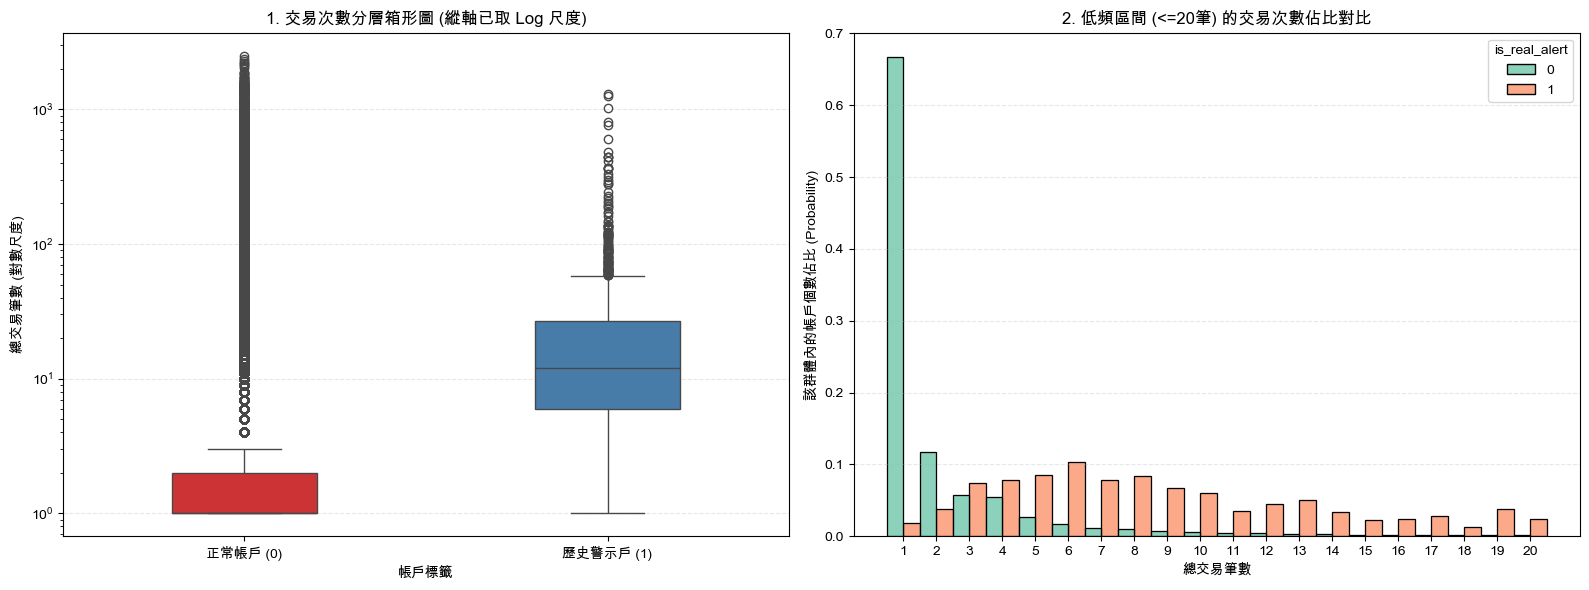

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 調整繪圖設定，確保中文與負號能正常顯示
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'Microsoft JhengHei', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False

print("步驟 1: 計算每個帳戶在交易明細中的【總交易筆數】(雙向加總)...")

# 1. 統計帳戶作為 From（轉出）與 To（轉入）的次數
from_counts = df_transaction['from_acct'].value_counts().to_frame('out_cnt')
to_counts = df_transaction['to_acct'].value_counts().to_frame('in_cnt')

# 2. Outer Join 串起全域所有獨立帳戶，並將缺失值補 0
df_acct_counts = pd.merge(from_counts, to_counts, left_index=True, right_index=True, how='outer').fillna(0)
df_acct_counts['total_txn_cnt'] = df_acct_counts['out_cnt'] + df_acct_counts['in_cnt']
df_acct_counts = df_acct_counts.reset_index().rename(columns={'index': 'acct'})

# 3. 依據 acct_alert.csv 精確貼上警示標籤
true_alert_set = set(df_alert['acct'])
df_acct_counts['is_real_alert'] = df_acct_counts['acct'].apply(lambda x: 1 if x in true_alert_set else 0)

# =========================================================================
# 步驟 2: 分層統計數字報告 (特別看 1 筆交易的魔鬼細節)
# =========================================================================
print("\n正常帳戶 vs. 歷史警示戶【交易次數】分位數分佈：")
print("=" * 75)
desc_compare = df_acct_counts.groupby('is_real_alert')['total_txn_cnt'].describe(
    percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]
).T
desc_compare.columns = ['正常帳戶 (0)', '歷史警示戶 (1)']
print(desc_compare)
print("=" * 75)

# 計算特定低頻交易帳戶的佔比
for label, name in [(0, '正常帳戶'), (1, '歷史警示戶')]:
    sub_df = df_acct_counts[df_acct_counts['is_real_alert'] == label]
    total_sub_accts = len(sub_df)
    cnt_1 = (sub_df['total_txn_cnt'] == 1).sum()
    cnt_less_5 = (sub_df['total_txn_cnt'] <= 5).sum()
    
    print(f"{name} 總計 {total_sub_accts:,} 個帳戶：")
    print(f"  歷史只有「剛好 1 筆」交易的帳戶數: {cnt_1:,} 個，佔該群體比例: {cnt_1/total_sub_accts*100:.2f}%")
    print(f"  歷史交易「小於等於 5 筆」的帳戶數: {cnt_less_5:,} 個，佔該群體比例: {cnt_less_5/total_sub_accts*100:.2f}%")
    print("-" * 75)

# =========================================================================
# 步驟 3: 繪製分層累積機率與分佈圖
# =========================================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# [左圖] 交易次數箱形圖 (由於極端離群值可能極大，縱軸採用對數尺度 Log Scale 才能看清箱體)
sns.boxplot(data=df_acct_counts, x='is_real_alert', y='total_txn_cnt', hue='is_real_alert', ax=axes[0], palette='Set1', width=0.4, legend=False)
axes[0].set_yscale('log')
axes[0].set_title('1. 交易次數分層箱形圖 (縱軸已取 Log 尺度)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('帳戶標籤')
axes[0].set_ylabel('總交易筆數 (對數尺度)')
axes[0].set_xticks([0, 1], labels=['正常帳戶 (0)', '歷史警示戶 (1)'])
axes[0].grid(axis='y', linestyle='--', alpha=0.3)

# [右圖] 低頻交易區間的直方圖對比 (精確觀察 1~20 筆之區間)
sns.histplot(data=df_acct_counts[df_acct_counts['total_txn_cnt'] <= 20], 
             x='total_txn_cnt', hue='is_real_alert', stat='probability', 
             common_norm=False, discrete=True, multiple='dodge', palette='Set2', ax=axes[1])
axes[1].set_title('2. 低頻區間 (<=20筆) 的交易次數佔比對比', fontsize=12, fontweight='bold')
axes[1].set_xlabel('總交易筆數')
axes[1].set_ylabel('該群體內的帳戶個數佔比 (Probability)')
axes[1].set_xticks(range(1, 21))
axes[1].grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

In [2]:
# 計算出這 443 萬筆交易明細的缺失值數量、缺失比例、以及不重複相異值個數
import pandas as pd

# 1. 計算缺失值與不重複值
missing_count = df_transaction.isnull().sum()
missing_ratio = (df_transaction.isnull().sum() / len(df_transaction)) * 100
cardinality = df_transaction.nunique()
data_types = df_transaction.dtypes

# 2. 合併成一個完整的數據完整性報告 DataFrame
integrity_report = pd.DataFrame({
    '資料型態 (Dtype)': data_types,
    '缺失值數量 (Missing Count)': missing_count,
    '缺失值比例 (Missing %)': missing_ratio.map("{:.2f}%".format),
    '相異值個數 (Cardinality)': cardinality
})

# 3. 顯示報告
print("📊 acct_transaction.csv 數據完整性與基數分析報告：")
print("-" * 75)
print(integrity_report)
print("-" * 75)

📊 acct_transaction.csv 數據完整性與基數分析報告：
---------------------------------------------------------------------------
               資料型態 (Dtype)  缺失值數量 (Missing Count) 缺失值比例 (Missing %)  \
from_acct            object                      0             0.00%   
from_acct_type        int64                      0             0.00%   
to_acct              object                      0             0.00%   
to_acct_type          int64                      0             0.00%   
is_self_txn          object                      0             0.00%   
txn_amt             float64                      0             0.00%   
txn_date              int64                      0             0.00%   
txn_time             object                      0             0.00%   
currency_type        object                      0             0.00%   
channel_type         object                      0             0.00%   

                相異值個數 (Cardinality)  
from_acct                    819399  
from_acct_type    

In [3]:
# 1. 總交易筆數
total_transactions = df_transaction.shape[0]

# 2. 計算不重複的帳戶數量
unique_from_accts = df_transaction['from_acct'].nunique()
unique_to_accts = df_transaction['to_acct'].nunique()

all_unique_accts = pd.concat([df_transaction['from_acct'], df_transaction['to_acct']]).nunique()

# ====== 顯示結果 ======
print(f"總交易筆數 (Total Transactions): {total_transactions:,} 筆")
print(f"獨立匯出帳戶數 (Unique From Accounts): {unique_from_accts:,} 個")
print(f"獨立匯入帳戶數 (Unique To Accounts): {unique_to_accts:,} 個")
print(f"交易網絡總獨立帳戶數 (Total Unique Accounts): {all_unique_accts:,} 個")

總交易筆數 (Total Transactions): 4,435,890 筆
獨立匯出帳戶數 (Unique From Accounts): 819,399 個
獨立匯入帳戶數 (Unique To Accounts): 1,169,482 個
交易網絡總獨立帳戶數 (Total Unique Accounts): 1,800,106 個


In [23]:
# 1. 計算全域交易網絡中的帳戶總數與分組數量
total_acct_count = len(df_night_prof)
normal_acct_count = (df_night_prof['is_real_alert'] == 0).sum()
alert_acct_count = (df_night_prof['is_real_alert'] == 1).sum()

# 2. 計算警示帳戶在全域帳戶中的極端不平衡比例
alert_ratio_pct = (alert_acct_count / total_acct_count) * 100

# ====== 顯示基礎帳戶統計報告 ======
print("全域交易網絡 帳戶底盤數量探勘報告：")
print("-" * 60)
print(f"交易網絡總獨立帳戶數 (Total Accounts) : {total_acct_count:,} 個 (100.0%)")
print(f"正常帳戶總數 (Normal Accounts, 0)   : {normal_acct_count:,} 個 ({normal_acct_count/total_acct_count*100:.2f}%)")
print(f"歷史警示帳戶總數 (Alert Accounts, 1) : {alert_acct_count:,} 個 ({alert_ratio_pct:.4f}%)")
print("-" * 60)
print(f"統計不平衡度對比： 正常戶 vs. 警示戶 = {int(normal_acct_count/alert_acct_count)} : 1")
print("-" * 60)

全域交易網絡 帳戶底盤數量探勘報告：
------------------------------------------------------------
交易網絡總獨立帳戶數 (Total Accounts) : 1,800,106 個 (100.0%)
正常帳戶總數 (Normal Accounts, 0)   : 1,799,102 個 (99.94%)
歷史警示帳戶總數 (Alert Accounts, 1) : 1,004 個 (0.0558%)
------------------------------------------------------------
統計不平衡度對比： 正常戶 vs. 警示戶 = 1791 : 1
------------------------------------------------------------


In [32]:
# 1. 建立匯出與匯入帳戶的集合 
set_from = set(df_transaction['from_acct'])
set_to = set(df_transaction['to_acct'])

# 2. 進行集合交集、差集運算
only_from = set_from - set_to          # 純匯出戶
only_to = set_to - set_from            # 純匯入戶
both_from_to = set_from & set_to       # 雙向交易戶
total_unique = set_from | set_to       # 總獨立帳戶數

# 3. 計算數量與比例
cnt_only_from = len(only_from)
cnt_only_to = len(only_to)
cnt_both = len(both_from_to)
cnt_total = len(total_unique)

# 4. 輸出結果報告
print("金流網絡節點角色：")
print("-" * 60)
print(f"總獨立帳戶數 (Total Unique): {cnt_total:,} 個 (100.0%)")
print(f"  ├─ 1. 純匯出帳戶 (Only From): {cnt_only_from:,} 個 ({cnt_only_from/cnt_total*100:.2f}%)")
print(f"  ├─ 2. 純匯入帳戶 (Only To)  : {cnt_only_to:,} 個 ({cnt_only_to/cnt_total*100:.2f}%)")
print(f"  └─ 3. 雙向交易帳戶 (Both)   : {cnt_both:,} 個 ({cnt_both/cnt_total*100:.2f}%)")
print("-" * 60)

金流網絡節點角色：
------------------------------------------------------------
總獨立帳戶數 (Total Unique): 1,800,106 個 (100.0%)
  ├─ 1. 純匯出帳戶 (Only From): 630,624 個 (35.03%)
  ├─ 2. 純匯入帳戶 (Only To)  : 980,707 個 (54.48%)
  └─ 3. 雙向交易帳戶 (Both)   : 188,775 個 (10.49%)
------------------------------------------------------------


步驟 0: 依據 acct_alert.csv 精確建立全域交易標籤與相對分鐘數...
步驟 1: 開始計算全域 180 萬帳戶的「行為統計特徵」...
🔗 步驟 2: 串聯雙向金流特徵並進行指標衍生...

數據探勘報告生成中...
【面向一：金額分佈特性與波動度均值對比】
is_real_alert      正常帳戶     歷史警示戶
out_skew       0.268421  1.104031
out_kurt       0.774997  3.166292
out_txn_cv     0.947131  1.083992
in_skew        0.172274  0.988721
in_kurt        0.492218  3.464085
in_txn_cv      0.932825  0.938023
----------------------------------------------------------------------
【面向三＆四：連續交易節奏與對手集中度均值對比】
is_real_alert                正常帳戶         歷史警示戶
txn_gap_min         668728.312433  25195.866534
unique_in_partners       1.230681     10.760956
unique_to_partners       1.232576      7.365538
max_all_hourly_cnt       1.686364      5.368526
max_hourly_ratio         0.800621      0.337616


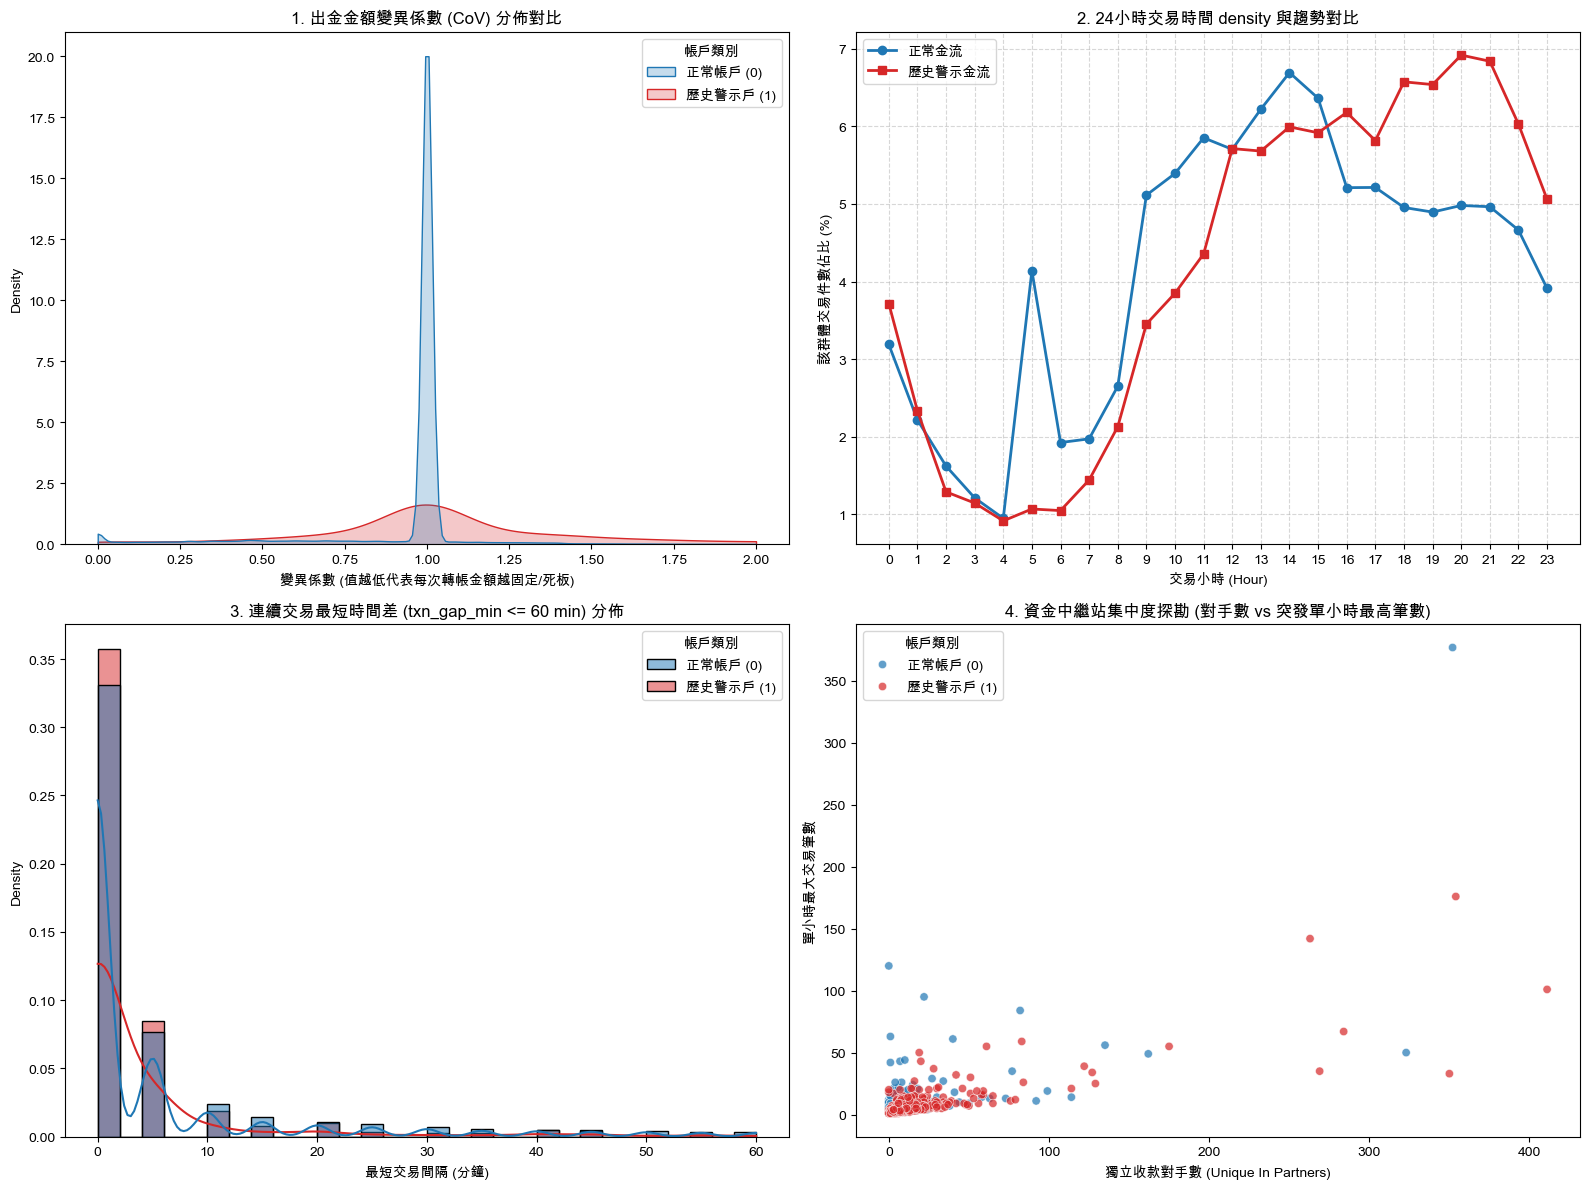

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 繪圖設定
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'Microsoft JhengHei', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False

print("步驟 0: 依據 acct_alert.csv 精確建立全域交易標籤與相對分鐘數...")
true_alert_set = set(df_alert['acct'])

# 使用更快的向量化方式標記交易
df_transaction['is_real_alert_txn'] = (
    df_transaction['from_acct'].isin(true_alert_set) | 
    df_transaction['to_acct'].isin(true_alert_set)
).astype(int)

# 改用 pandas 內建向量化字串切片或 datetime 解析
time_parts = df_transaction['txn_time'].str.split(':')
df_transaction['txn_hour'] = time_parts.str[0].astype(int)
df_transaction['txn_minute'] = time_parts.str[1].astype(int)
df_transaction['total_minutes'] = df_transaction['txn_date'] * 1440 + df_transaction['txn_hour'] * 60 + df_transaction['txn_minute']

# =========================================================================
# 核心運算：依據帳戶進行四大維度深度聚合
# =========================================================================
print("步驟 1: 開始計算全域 180 萬帳戶的「行為統計特徵」...")

# (A) 轉出行為聚合
df_transaction = df_transaction.sort_values(by=['from_acct', 'total_minutes'])
df_transaction['out_gap'] = df_transaction.groupby('from_acct')['total_minutes'].diff()

# 計算單個小時最大出金筆數
hourly_out_max = df_transaction.groupby(['from_acct', 'txn_hour'], observed=False).size().groupby('from_acct').max().to_frame('max_hourly_out_cnt').reset_index().rename(columns={'from_acct': 'acct'})

df_from_prof = df_transaction.groupby('from_acct', observed=False).agg(
    out_cnt=('txn_amt', 'count'),
    out_sum=('txn_amt', 'sum'),
    out_mean=('txn_amt', 'mean'),
    out_std=('txn_amt', 'std'),  # 只有 1 筆交易時自動保持為 NaN
    out_skew=('txn_amt', lambda x: x.skew() if len(x) > 2 else 0),  
    out_kurt=('txn_amt', lambda x: x.kurt() if len(x) > 3 else 0),  
    unique_to_partners=('to_acct', 'nunique'),
    out_gap_min=('out_gap', 'min'), # 💡 只有 1 筆交易時自動保持為 NaN
).reset_index().rename(columns={'from_acct': 'acct'})

df_from_prof = df_from_prof.merge(hourly_out_max, on='acct', how='left')


# (B) 轉入行為聚合
df_transaction = df_transaction.sort_values(by=['to_acct', 'total_minutes'])
df_transaction['in_gap'] = df_transaction.groupby('to_acct')['total_minutes'].diff()

# 計算單個小時最大入金筆數
hourly_in_max = df_transaction.groupby(['to_acct', 'txn_hour'], observed=False).size().groupby('to_acct').max().to_frame('max_hourly_in_cnt').reset_index().rename(columns={'to_acct': 'acct'})

df_to_prof = df_transaction.groupby('to_acct', observed=False).agg(
    in_cnt=('txn_amt', 'count'),
    in_sum=('txn_amt', 'sum'),
    in_mean=('txn_amt', 'mean'),
    in_std=('txn_amt', 'std'),   # 💡 只有 1 筆交易時自動保持為 NaN
    in_skew=('txn_amt', lambda x: x.skew() if len(x) > 2 else 0),   
    in_kurt=('txn_amt', lambda x: x.kurt() if len(x) > 3 else 0),   
    unique_in_partners=('from_acct', 'nunique'),
    in_gap_min=('in_gap', 'min'), # 💡 只有 1 筆交易時自動保持為 NaN
).reset_index().rename(columns={'to_acct': 'acct'})

df_to_prof = df_to_prof.merge(hourly_in_max, on='acct', how='left')

# =========================================================================
# 步驟 2: 雙向特徵串接與衍生洗錢特徵工程 
# =========================================================================
print("🔗 步驟 2: 串聯雙向金流特徵並進行指標衍生...")

df_explorer = pd.merge(df_from_prof, df_to_prof, on='acct', how='outer')

# 嚴格確認帳戶層級的標籤
df_explorer['is_real_alert'] = df_explorer['acct'].apply(lambda x: 1 if x in true_alert_set else 0)

# 指標 1: 金額變異係數 (CoV = std / mean) 
df_explorer['out_txn_cv'] = (df_explorer['out_std'] / (df_explorer['out_mean'] + 1e-5)).fillna(1.0)
df_explorer['in_txn_cv'] = (df_explorer['in_std'] / (df_explorer['in_mean'] + 1e-5)).fillna(1.0)

# 指標 2: 最短交易間隔時間
df_explorer['txn_gap_min'] = df_explorer[['out_gap_min', 'in_gap_min']].min(axis=1)
# 完全沒有連續交易記錄（意即歷史上雙向都只發生過一次交易）的帳戶，填補代表常態的極大值（999,999 分鐘）
df_explorer['txn_gap_min'] = df_explorer['txn_gap_min'].fillna(999999)

# 指標 3: 單小時最大交易筆數與比例
# 先將其餘計數、金額類欄位安全補 0，以便進行加總運算
fill_zero_cols = [
    'out_cnt', 'out_sum', 'out_mean', 'out_std', 'max_hourly_out_cnt',
    'in_cnt', 'in_sum', 'in_mean', 'in_std', 'max_hourly_in_cnt',
    'unique_to_partners', 'unique_in_partners', 'out_gap_min', 'in_gap_min'
]
df_explorer[fill_zero_cols] = df_explorer[fill_zero_cols].fillna(0)

total_cnt = df_explorer['out_cnt'] + df_explorer['in_cnt'] + 1e-5
max_hourly_cnt = df_explorer[['max_hourly_out_cnt', 'max_hourly_in_cnt']].max(axis=1)
df_explorer['max_all_hourly_cnt'] = max_hourly_cnt
df_explorer['max_hourly_ratio'] = max_hourly_cnt / total_cnt


# =========================================================================
# 步驟 3: 分析師視覺化與數值對比報告
# =========================================================================
print("\n數據探勘報告生成中...")
print("=" * 70)

amt_cols = ['out_skew', 'out_kurt', 'out_txn_cv', 'in_skew', 'in_kurt', 'in_txn_cv']
print("【面向一：金額分佈特性與波動度均值對比】")
print(df_explorer.groupby('is_real_alert')[amt_cols].mean().T.rename(columns={0: '正常帳戶', 1: '歷史警示戶'}))
print("-" * 70)

net_cols = ['txn_gap_min', 'unique_in_partners', 'unique_to_partners', 'max_all_hourly_cnt', 'max_hourly_ratio']
print("【面向三＆四：連續交易節奏與對手集中度均值對比】")
print(df_explorer.groupby('is_real_alert')[net_cols].mean().T.rename(columns={0: '正常帳戶', 1: '歷史警示戶'}))
print("=" * 70)

# =========================================================================
# 步驟 4: 繪製探勘視覺化圖表
# =========================================================================
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 0 正常藍，1 警示紅
custom_colors = {0: 'tab:blue', 1: 'tab:red'}

# 圖一：金額波動度 (CoV) 
sns.kdeplot(data=df_explorer, x='out_txn_cv', hue='is_real_alert', fill=True, common_norm=False, palette=custom_colors, clip=(0, 2), ax=axes[0, 0])
axes[0, 0].set_title('1. 出金金額變異係數 (CoV) 分佈對比', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('變異係數 (值越低代表每次轉帳金額越固定/死板)')
if axes[0, 0].get_legend() is not None:
    axes[0, 0].get_legend().set_title('帳戶類別')
    for text, label in zip(axes[0, 0].get_legend().get_texts(), ['正常帳戶 (0)', '歷史警示戶 (1)']):
        text.set_text(label)

# 圖二：24小時交易時間折線圖
hourly_trend = df_transaction.groupby(['is_real_alert_txn', 'txn_hour']).size().unstack(level=0).fillna(0)
hourly_trend_pct = (hourly_trend / hourly_trend.sum()) * 100
axes[0, 1].plot(hourly_trend_pct.index, hourly_trend_pct[0], marker='o', color='tab:blue', linewidth=2, label='正常金流')
axes[0, 1].plot(hourly_trend_pct.index, hourly_trend_pct[1], marker='s', color='tab:red', linewidth=2, label='歷史警示金流')
axes[0, 1].set_title('2. 24小時交易時間 density 與趨勢對比', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('交易小時 (Hour)')
axes[0, 1].set_ylabel('該群體交易件數佔比 (%)')
axes[0, 1].set_xticks(range(0, 24))
axes[0, 1].legend()
axes[0, 1].grid(True, linestyle='--', alpha=0.5)

# 圖三：連續交易最短時間差 (txn_gap_min)
sns.histplot(data=df_explorer[df_explorer['txn_gap_min'] <= 60], x='txn_gap_min', hue='is_real_alert', 
             stat='density', common_norm=False, bins=30, kde=True, palette=custom_colors, ax=axes[1, 0])
axes[1, 0].set_title('3. 連續交易最短時間差 (txn_gap_min <= 60 min) 分佈', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('最短交易間隔 (分鐘)')
if axes[1, 0].get_legend() is not None:
    axes[1, 0].get_legend().set_title('帳戶類別')
    for text, label in zip(axes[1, 0].get_legend().get_texts(), ['正常帳戶 (0)', '歷史警示戶 (1)']):
        text.set_text(label)

# 圖四：中繼站集中度探勘
df_normal_sample = df_explorer[df_explorer['is_real_alert'] == 0].sample(n=5000, random_state=42)
df_alert_full = df_explorer[df_explorer['is_real_alert'] == 1]
df_scatter_plot = pd.concat([df_normal_sample, df_alert_full])


sns.scatterplot(data=df_scatter_plot, x='unique_in_partners', y='max_all_hourly_cnt', hue='is_real_alert', 
                alpha=0.7, palette=custom_colors, ax=axes[1, 1])
axes[1, 1].set_title('4. 資金中繼站集中度探勘 (對手數 vs 突發單小時最高筆數)', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('獨立收款對手數 (Unique In Partners)')
axes[1, 1].set_ylabel('單小時最大交易筆數')
if axes[1, 1].get_legend() is not None:
    axes[1, 1].get_legend().set_title('帳戶類別')
    for text, label in zip(axes[1, 1].get_legend().get_texts(), ['正常帳戶 (0)', '歷史警示戶 (1)']):
        text.set_text(label)

plt.tight_layout()
plt.show()

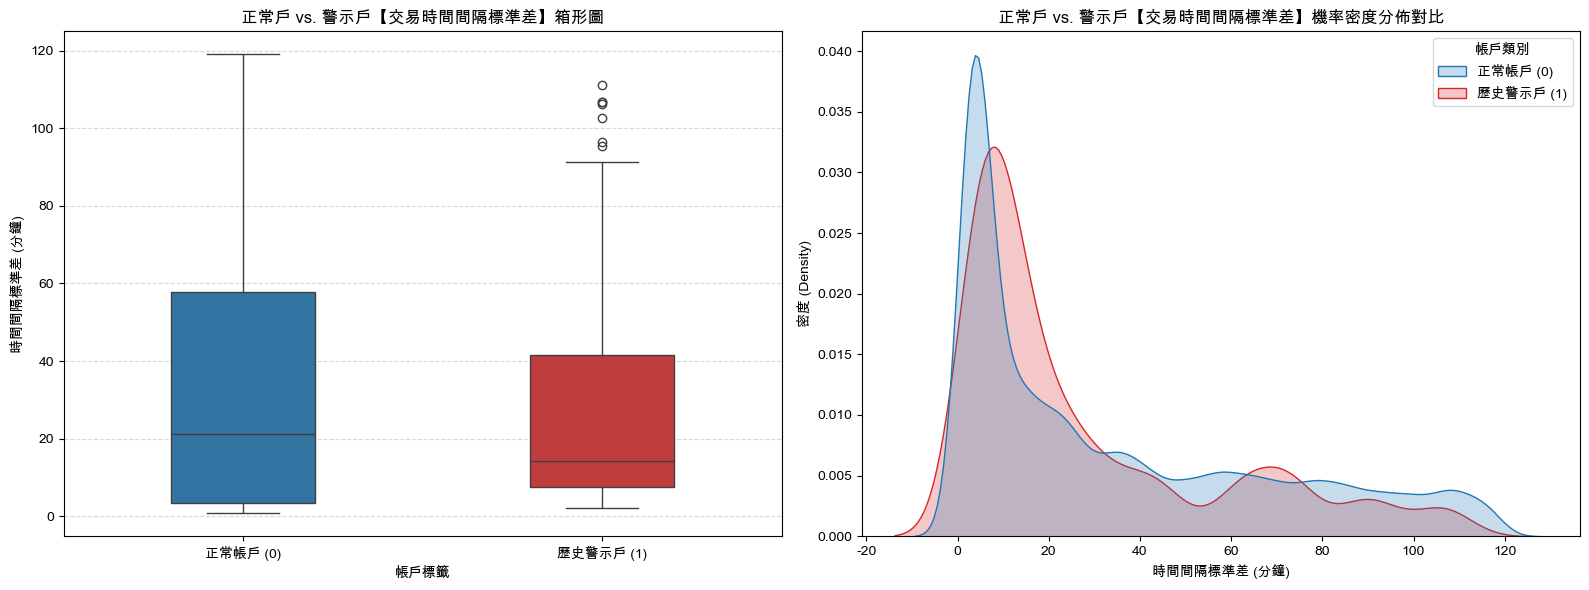

【交易時間間隔標準差】詳細百分位數分佈（分鐘）：
-----------------------------------------------------------------
                  count          mean           std       min          10%  \
is_real_alert                                                                
0              406703.0  17027.580514  15340.482691  0.777556  2343.152285   
1                 934.0   7102.368531   8978.340851  2.236068    21.964350   

                       25%           50%           75%           90%  \
is_real_alert                                                          
0              6088.189386  13546.001870  22213.759531  35655.859441   
1               570.788994   3804.128909  10717.764331  18305.389951   

                         max  
is_real_alert                 
0              121576.404423  
1               52428.432291  
-----------------------------------------------------------------


In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'Microsoft JhengHei', 'SimHei', 'sans-serif']
plt.rcParams['axes.unicode_minus'] = False

# 因為連續交易最短時間差看不出顯著差異，嘗試繪製交易時間間隔標準差
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 排除單向帳戶被誤補為 0 的雜訊，並限制在 120 分鐘（2小時）內以便精準觀察高頻走帳時段
df_std_filtered = df_explorer[(df_explorer['txn_gap_std'] > 0) & (df_explorer['txn_gap_std'] <= 120)]

custom_colors = {0: 'tab:blue', 1: 'tab:red'}

# 1. 箱形圖 (Boxplot)
sns.boxplot(
    data=df_std_filtered, 
    x='is_real_alert', 
    y='txn_gap_std', 
    hue='is_real_alert',  
    ax=axes[0], 
    palette=custom_colors,  
    width=0.4,
    legend=False  
)
axes[0].set_title('正常戶 vs. 警示戶【交易時間間隔標準差】箱形圖', fontsize=12, fontweight='bold')
axes[0].set_xlabel('帳戶標籤')
axes[0].set_ylabel('時間間隔標準差 (分鐘)')

# 設定 X 軸刻度與標籤
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['正常帳戶 (0)', '歷史警示戶 (1)'])
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

# 2. 機率密度圖
sns.kdeplot(
    data=df_std_filtered, 
    x='txn_gap_std', 
    hue='is_real_alert', 
    fill=True, 
    common_norm=False, 
    palette=custom_colors,  
    ax=axes[1], 
    bw_adjust=0.5
)
axes[1].set_title('正常戶 vs. 警示戶【交易時間間隔標準差】機率密度分佈對比', fontsize=12, fontweight='bold')
axes[1].set_xlabel('時間間隔標準差 (分鐘)')
axes[1].set_ylabel('密度 (Density)')

axes[1].get_legend().set_title('帳戶類別')
for text, label in zip(axes[1].get_legend().get_texts(), ['正常帳戶 (0)', '歷史警示戶 (1)']):
    text.set_text(label)

plt.tight_layout()
plt.show()

# ==========================================
# 列印分位數細節，用數字解讀真相
# ==========================================
print("【交易時間間隔標準差】詳細百分位數分佈（分鐘）：")
print("-" * 65)
print(df_explorer[df_explorer['txn_gap_std'] > 0].groupby('is_real_alert')['txn_gap_std'].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9]))
print("-" * 65)

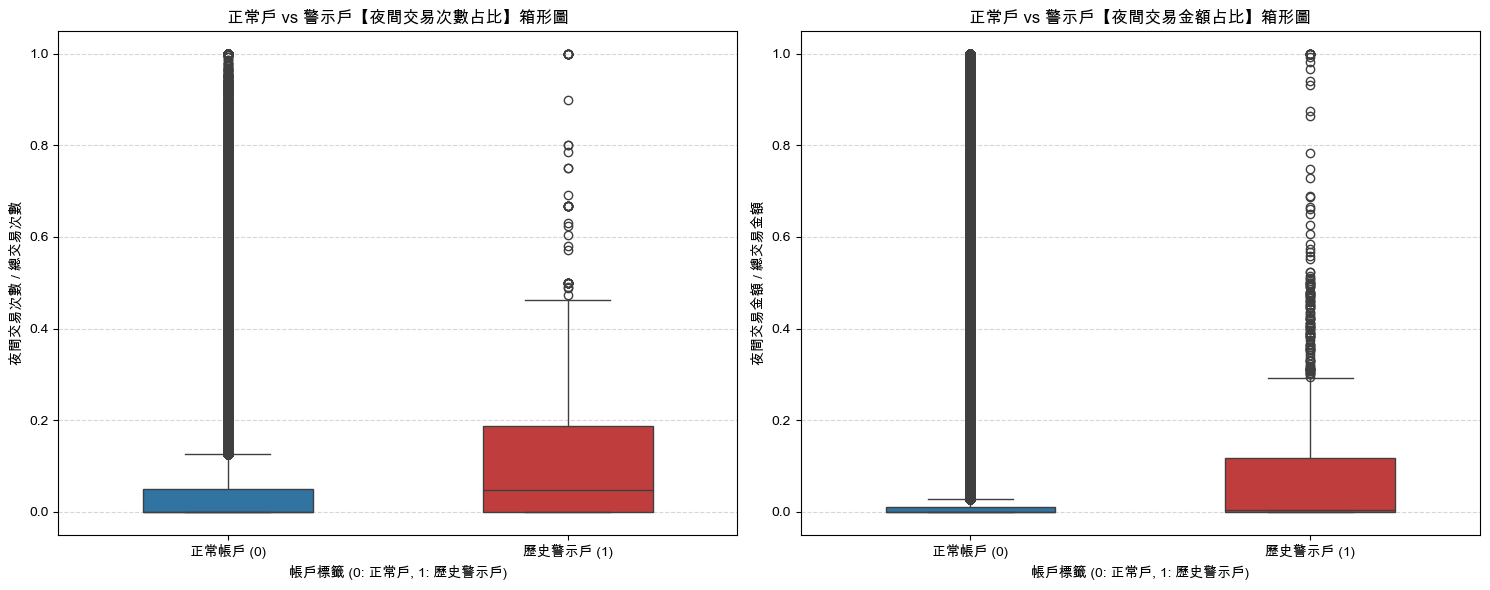

【夜間交易次數占比】詳細百分位數分佈：
------------------------------------------------------------
                   count      mean       std  min  25%       50%     75%  \
is_real_alert                                                              
0              1799102.0  0.167725  0.340421  0.0  0.0  0.000000  0.0500   
1                 1004.0  0.118015  0.171962  0.0  0.0  0.046537  0.1875   

                    90%       95%       max  
is_real_alert                                
0              0.999990  0.999990  1.000000  
1              0.333332  0.428571  0.999999  

【夜間交易金額占比】詳細百分位數分佈：
------------------------------------------------------------
                   count     mean       std  min  25%       50%       75%  \
is_real_alert                                                               
0              1799102.0  0.16795  0.345694  0.0  0.0  0.000000  0.010737   
1                 1004.0  0.10097  0.184643  0.0  0.0  0.003233  0.117732   

                    90%       95%  max 

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 調整繪圖設定
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'Microsoft JhengHei', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 繪製帳戶層級夜間交易占比箱形圖
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

custom_colors = {0: 'tab:blue', 1: 'tab:red'}

# 1. 夜間交易次數占比箱形圖
sns.boxplot(
    data=df_night_prof, 
    x='is_real_alert', 
    y='night_cnt_ratio', 
    hue='is_real_alert', 
    ax=axes[0], 
    palette=custom_colors,
    width=0.5,
    legend=False
)
axes[0].set_title('正常戶 vs 警示戶【夜間交易次數占比】箱形圖', fontsize=12, fontweight='bold')
axes[0].set_xlabel('帳戶標籤 (0: 正常戶, 1: 歷史警示戶)', fontsize=10)
axes[0].set_ylabel('夜間交易次數 / 總交易次數', fontsize=10)
axes[0].set_xticks([0, 1])  # 優化：先指定 ticks 位置，避免新版警告
axes[0].set_xticklabels(['正常帳戶 (0)', '歷史警示戶 (1)'])
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

# 2. 夜間交易金額占比箱形圖
sns.boxplot(
    data=df_night_prof, 
    x='is_real_alert', 
    y='night_sum_ratio', 
    hue='is_real_alert',  
    ax=axes[1], 
    palette=custom_colors,
    width=0.5,
    legend=False
)
axes[1].set_title('正常戶 vs 警示戶【夜間交易金額占比】箱形圖', fontsize=12, fontweight='bold')
axes[1].set_xlabel('帳戶標籤 (0: 正常戶, 1: 歷史警示戶)', fontsize=10)
axes[1].set_ylabel('夜間交易金額 / 總交易金額', fontsize=10)
axes[1].set_xticks([0, 1])  # 優化：先指定 ticks 位置，避免新版警告
axes[1].set_xticklabels(['正常帳戶 (0)', '歷史警示戶 (1)'])
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# ==========================================
# 列印分位數細節，輔助解讀箱形圖邊界
# ==========================================
print("【夜間交易次數占比】詳細百分位數分佈：")
print("-" * 60)
print(df_night_prof.groupby('is_real_alert')['night_cnt_ratio'].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95]))
print("\n【夜間交易金額占比】詳細百分位數分佈：")
print("-" * 60)
print(df_night_prof.groupby('is_real_alert')['night_sum_ratio'].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95]))